(pdf:hyperbolic:non-convex)=
# Non-convex hyperbolic problems

In this section, non-convex hyperbolic problems are briefly discussed using a non-linear scalar equation as a toy problem to show their characteristics. The main topic is the solution of a Riemann problem. *Depending on the initial conditions*, the solution of the Rieamnn problem for a non-convex hyperbolic scalar equation may involve not only simple waves (like shock or rarefaction), but also **composite waves**, combining both a shock and a rarefaction.

First, a [numerical simulation](pdf:hyperbolic:non-convex:toy-problem:numerical) of a Riemann problem the viscous counterpart of the hyperbolic equation is performed and the solution is discussed. Then, the solution is discussed introducing the [**Olenik criterion**](pdf:hyperbolic:non-convex:toy-problem:olenik) to find the physical solution.


(pdf:hyperbolic:non-convex:toy-problem)=
## Toy problem

The non-linear scalar equation

$$\partial_t u + \partial_x F(u) = 0 \ ,$$

with flux $F(u) = u^3$ is a hyperbolic equation with non-convex flux, as 

$$F''(u) = 6 u \left\{ \begin{aligned} > 0 && \text{for $u > 0$} \\ \le 0 && \text{for $u \le 0$} \end{aligned} \right.$$


(pdf:hyperbolic:non-convex:toy-problem:numerical)=
### Numerical simulation

The numerical simulation of two Riemann problem of the viscous counterpart of the hyperbolic equation,

$$\partial_t u + \partial_x F(u) - \partial_x ( \nu \partial_x u ) = 0 \ ,$$

is performed here with a time-explicit finite-difference method for two different initial conditions: $1)$ $(u_L, u_R) = (-1, 1)$, $2)$ $(u_L, u_R) = (1,-1)$.

Here, the value of the diffusion coefficient is choosen as $\nu = .05$ as a compromise between thickness of the "shock" and the stability requirement of the numerical method.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
# from tqdm import tqdm

#> Parameters
nu = .05
x0, x1 = -4., 4.

#> Discretization
nx = 201
dt = .001

#> Domain
xv = np.linspace(x0, x1, nx)
dx = xv[1] - xv[0]

#> Flux
flux = lambda u: u**3
dflux = lambda u: 3*u**2

#### Simulation with $(u_L, u_R) = (-1,1)$

The solution is the combination of a left shock between state $u_L = -1$ and an intermediate state $u^* = \frac{1}{2}$, and a right fan between $u^*$ and $u_R = 1$.

In [2]:
#> Initial conditions
uL, uR = -1., 1.
u0 = uR * np.ones(nx)
u0[xv < 0.] = uL

it = 0
t = 0.
tv = [ t ]

u = u0.copy()
U = [ u.copy() ]

for it in range(1000):
    
    u_minus = .5 * ( u[ :-2] + u[1:-1] );  f_minus = flux(u_minus)
    u_plus  = .5 * ( u[1:-1] + u[2:  ] );  f_plus  = flux(u_plus)

    u[1:-1] -= dt * ( ( f_plus - f_minus ) / dx - nu * ( u[2:] - 2*u[1:-1] + u[:-2] ) / dx**2 )

    t += dt

    U.append(u.copy())
    tv.append(t)


U = np.array(U)
tv = np.array(tv)

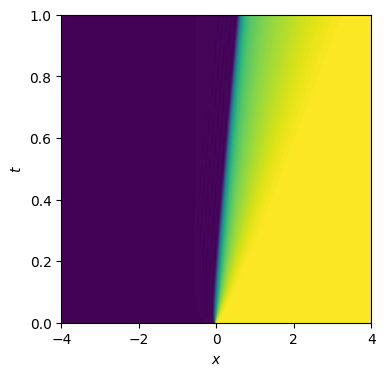

In [3]:
#> x-t diagram
fig, ax = plt.subplots(1,1, figsize=(4,4))
X, T = np.meshgrid(xv, tv)
ax.contourf(X, T, U, 100)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$t$')
plt.show()


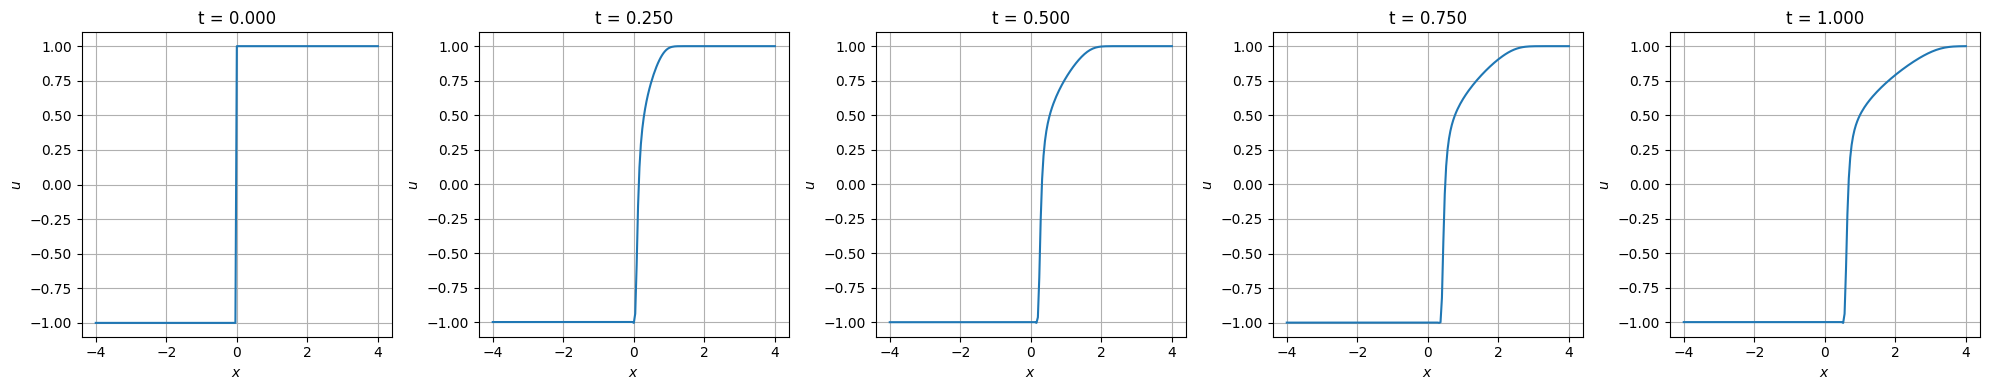

In [4]:
#> u(x,t) 
n_plots = 4
nt = len(tv)
dn_plot = int( np.floor(nt/n_plots) )

fig, ax = plt.subplots(1,n_plots+1, figsize=(4*(n_plots+1),4))

for i_plot in range(n_plots+1):
    ax[i_plot].plot(xv, U[dn_plot*i_plot,:])
    ax[i_plot].set_xlabel(r'$x$')
    ax[i_plot].set_ylabel(r'$u$')
    ax[i_plot].set_title(f't = {tv[dn_plot*i_plot]:.3f}')
    ax[i_plot].grid()

plt.tight_layout()
plt.show()

#### Simulation with $(u_L, u_R) = (1,-1)$

The solution is the combination of a left shock between state $u_L = 1$ and an intermediate state $u^* = \frac{1}{2}$, and a right fan between $u^*$ and $u_R = -1$.

In [5]:
#> Initial conditions
uL, uR = 1., -1.
u0 = uR * np.ones(nx)
u0[xv < 0.] = uL

it = 0
t = 0.
tv = [ t ]

u = u0.copy()
U = [ u.copy() ]

for it in range(1000):
    
    u_minus = .5 * ( u[ :-2] + u[1:-1] );  f_minus = flux(u_minus)
    u_plus  = .5 * ( u[1:-1] + u[2:  ] );  f_plus  = flux(u_plus)

    u[1:-1] -= dt * ( ( f_plus - f_minus ) / dx - nu * ( u[2:] - 2*u[1:-1] + u[:-2] ) / dx**2 )

    t += dt

    U.append(u.copy())
    tv.append(t)


U = np.array(U)
tv = np.array(tv)

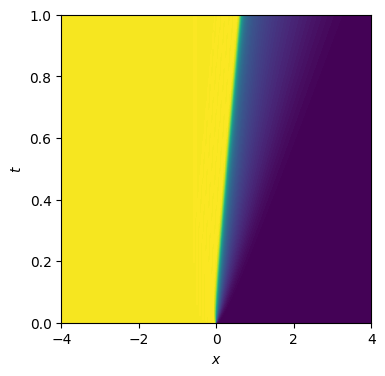

In [6]:
#> x-t diagram
fig, ax = plt.subplots(1,1, figsize=(4,4))
X, T = np.meshgrid(xv, tv)
ax.contourf(X, T, U, 100)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$t$')
plt.show()


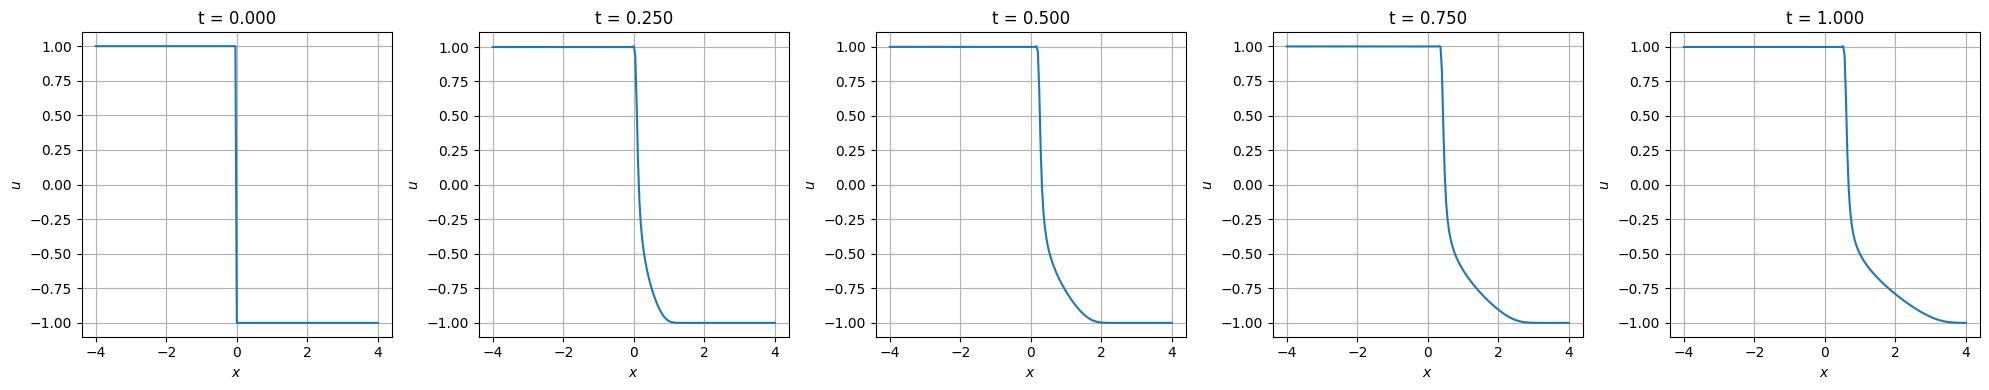

In [7]:
#> u(x,t) 
n_plots = 4
nt = len(tv)
dn_plot = int( np.floor(nt/n_plots) )

fig, ax = plt.subplots(1,n_plots+1, figsize=(4*(n_plots+1),4))

for i_plot in range(n_plots+1):
    ax[i_plot].plot(xv, U[dn_plot*i_plot,:])
    ax[i_plot].set_xlabel(r'$x$')
    ax[i_plot].set_ylabel(r'$u$')
    ax[i_plot].set_title(f't = {tv[dn_plot*i_plot]:.3f}')
    ax[i_plot].grid()

plt.tight_layout()
plt.show()


(pdf:hyperbolic:non-convex:toy-problem:olenik)=
### Olenik's criterion

In a Riemann problem with two values $u_L$, $u_R$, with $F''(u_L) F''(u_R) < 0$ - so that non-convexity manifests itself, and assuming that $F''(u)$ changes sign only once (see the comment below for more complex flux functions -, a composite wave occurs. This composite wave is composed of a rarefaction wave and a shock wave.

The intermediate state $u^*$ is found with the condition that the speed of the shock equals the characteristic speed of the fan at the shock, i.e.

$$s(u_L, u^*) = F'(u^*) \ ,$$

or

$$\frac{F(u^*) - F(u_L)}{u^* - u_L} = F'(u^*) \ .$$

i.e. the slope $F'(u^*)$ of the tangent line at $F(u)$ in $u^*$ equals the slope of the line connecting the state $(\cdot)^*$ with $(\cdot)_L$. This condition prevents characteristic lines from originating from the shock. 

**todo**
* With more "complex" flux functions $F(u)$ (that have several ranges of $u$-values where $F''(u)$ changes sign), how many waves in the composite wave? Show how Olenik's criterion applies.

#### $(u_L, u_R) = (-1, 1)$

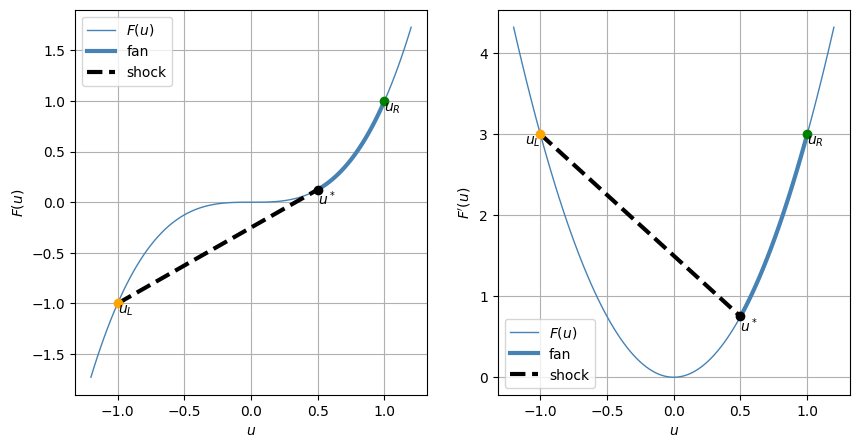

In [8]:
uL, uR = -1., 1.
us = .5

fig, ax = plt.subplots(1,2, figsize=(10,5))

uv = np.linspace(-1.2, 1.2, 100)
fuv = flux(uv)
dfuv = dflux(uv)

uv_sR = np.linspace(us, uR, 100)
fuv_sR = flux(uv_sR)
dfuv_sR = dflux(uv_sR)

ax[0].plot(uv   , fuv   , lw=1., color='steelblue', label=r'$F(u)$')
ax[0].plot(uv_sR, fuv_sR, lw=3., color='steelblue', label=r'fan'   )
ax[0].plot([uL, us], [flux(uL), flux(us)], 'k--', lw=3, label='shock')
ax[0].plot(uL, flux(uL), 'o', color='orange'); ax[0].text(uL, flux(uL), r'$u_L$', va='top')
ax[0].plot(uR, flux(uR), 'o', color='green' ); ax[0].text(uR, flux(uR), r'$u_R$', va='top')
ax[0].plot(us, flux(us), 'o', color='black' ); ax[0].text(us, flux(us), r'$u^*$', va='top')
ax[0].set_xlabel(r'$u$')
ax[0].set_ylabel(r'$F(u)$')
ax[0].legend()
ax[0].grid()


ax[1].plot(uv   , dfuv   , lw=1., color='steelblue', label=r'$F(u)$')
ax[1].plot(uv_sR, dfuv_sR, lw=3., color='steelblue', label=r'fan'   )
ax[1].plot([uL, us], [dflux(uL), dflux(us)], 'k--', lw=3, label='shock')
ax[1].plot(uL, dflux(uL), 'o', color='orange'); ax[1].text(uL, dflux(uL), r'$u_L$', va='top', ha='right')
ax[1].plot(uR, dflux(uR), 'o', color='green' ); ax[1].text(uR, dflux(uR), r'$u_R$', va='top')
ax[1].plot(us, dflux(us), 'o', color='black' ); ax[1].text(us, dflux(us), r'$u^*$', va='top')
ax[1].set_xlabel(r'$u$')
ax[1].set_ylabel(r"$F'(u)$")
ax[1].legend()
ax[1].grid()

plt.show()


#### $(u_L, u_R) = (1, -1)$

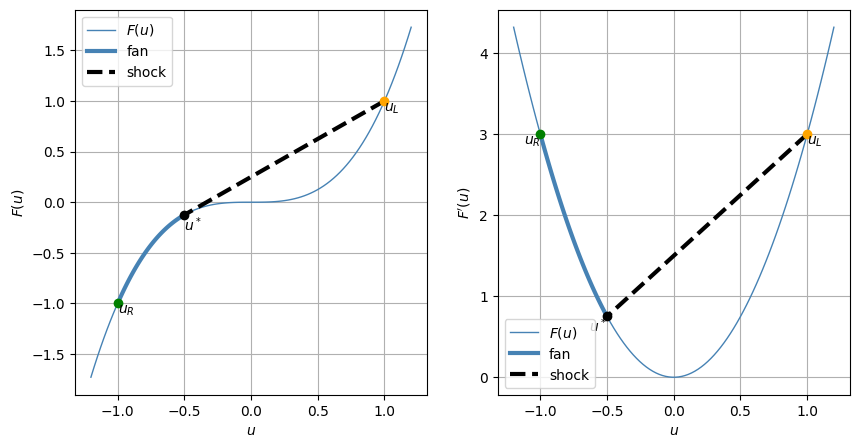

In [9]:
uL, uR = 1., -1.
us = -.5

fig, ax = plt.subplots(1,2, figsize=(10,5))

uv = np.linspace(-1.2, 1.2, 100)
fuv = flux(uv)
dfuv = dflux(uv)

uv_sR = np.linspace(us, uR, 100)
fuv_sR = flux(uv_sR)
dfuv_sR = dflux(uv_sR)

ax[0].plot(uv   , fuv   , lw=1., color='steelblue', label=r'$F(u)$')
ax[0].plot(uv_sR, fuv_sR, lw=3., color='steelblue', label=r'fan'   )
ax[0].plot([uL, us], [flux(uL), flux(us)], 'k--', lw=3, label='shock')
ax[0].plot(uL, flux(uL), 'o', color='orange'); ax[0].text(uL, flux(uL), r'$u_L$', va='top')
ax[0].plot(uR, flux(uR), 'o', color='green' ); ax[0].text(uR, flux(uR), r'$u_R$', va='top')
ax[0].plot(us, flux(us), 'o', color='black' ); ax[0].text(us, flux(us), r'$u^*$', va='top')
ax[0].set_xlabel(r'$u$')
ax[0].set_ylabel(r'$F(u)$')
ax[0].legend()
ax[0].grid()


ax[1].plot(uv   , dfuv   , lw=1., color='steelblue', label=r'$F(u)$')
ax[1].plot(uv_sR, dfuv_sR, lw=3., color='steelblue', label=r'fan'   )
ax[1].plot([uL, us], [dflux(uL), dflux(us)], 'k--', lw=3, label='shock')
ax[1].plot(uL, dflux(uL), 'o', color='orange'); ax[1].text(uL, dflux(uL), r'$u_L$', va='top', ha='left')
ax[1].plot(uR, dflux(uR), 'o', color='green' ); ax[1].text(uR, dflux(uR), r'$u_R$', va='top', ha='right')
ax[1].plot(us, dflux(us), 'o', color='black' ); ax[1].text(us, dflux(us), r'$u^*$', va='top', ha='right')
ax[1].set_xlabel(r'$u$')
ax[1].set_ylabel(r"$F'(u)$")
ax[1].legend()
ax[1].grid()

plt.show()
